# ProfNER: Detecting Profession Mentions in Tweets

Binary classification task: does a tweet mention a healthcare profession? Built on
the [ProfNER](https://temu.bsc.es/smm4h-spanish) shared task, using tweets from the
COVID-19 pandemic ([dataset on Hugging Face](https://huggingface.co/datasets/luisgasco/profner_classification_master)).

This notebook covers the exploratory analysis. Model training lives in `src/` --
`src/baseline.py` (TF-IDF + Logistic Regression, runs in seconds on CPU) and
`src/train.py` (BERTIN RoBERTa fine-tuning, needs a GPU). See the README for the
full results comparison and a discussion of whether the transformer's cost is
justified here.

## Load data

In [1]:
import sys
from pathlib import Path

# Make the `src` package importable when this notebook runs from notebooks/
if Path.cwd().name == "notebooks":
    sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

from src.preprocess import DATASET_NAME, clean_text

dataset = load_dataset(DATASET_NAME)
train_df = dataset["train"].to_pandas()
val_df = dataset["validation"].to_pandas()
test_df = dataset["test"].to_pandas()

print(f"Train: {len(train_df)}  Validation: {len(val_df)}  Test: {len(test_df)}")

C:\Users\Usuario\.pyenv\pyenv-win\versions\3.11.9\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Train: 2786  Validation: 999  Test: 1001


## Class balance and data quality

In [2]:
print("Duplicates -- train:", train_df.duplicated().sum(),
      "val:", val_df.duplicated().sum(), "test:", test_df.duplicated().sum())
print("\nMissing values (train):")
print(train_df.isna().sum())

print("\nTrain label counts:")
print(train_df["label"].value_counts())
print("\nValidation label counts:")
print(val_df["label"].value_counts())

Duplicates -- train: 0 val: 0 test: 0

Missing values (train):
tweet_id    0
text        0
label       0
dtype: int64

Train label counts:
label
1    1393
0    1393
Name: count, dtype: int64

Validation label counts:
label
0    761
1    238
Name: count, dtype: int64


Train is artificially balanced (1,393 positive / 1,393 negative). Validation keeps
the natural class distribution instead: 238 positive / 761 negative, roughly 24%
positive. That mismatch matters -- production traffic will look like validation
(and test), not train, which is exactly why both the baseline and BERTIN are
trained with class weighting rather than assuming a 50/50 split at inference.

## Tweet length by class

C:\Users\Usuario\AppData\Local\Temp\ipykernel_14676\3025974100.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["No profession (0)", "Mentions profession (1)"])


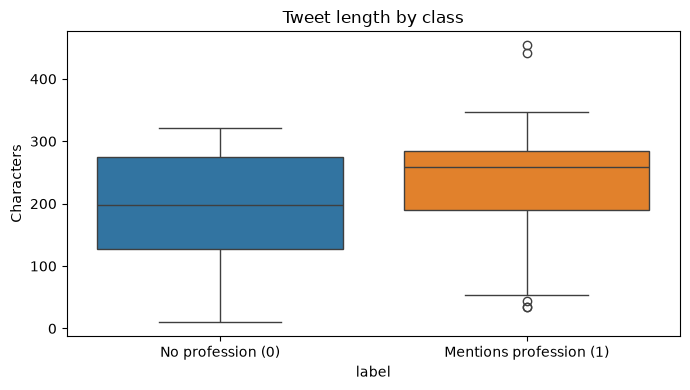

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,1393.0,193.451543,82.383229,10.0,127.0,198.0,274.0,321.0
1,1393.0,236.663317,64.759120,34.0,190.0,259.0,285.0,454.0


In [3]:
train_df["char_length"] = train_df["text"].apply(len)

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=train_df, x="label", y="char_length", hue="label", ax=ax, legend=False)
ax.set_xticklabels(["No profession (0)", "Mentions profession (1)"])
ax.set_ylabel("Characters")
ax.set_title("Tweet length by class")
plt.tight_layout()
plt.show()

train_df.groupby("label")["char_length"].describe()

Tweets mentioning a profession run noticeably longer (mean ~237 characters, median
~259) than tweets that don't (mean ~193, median ~198). Users appear to add more
context when naming a profession -- worth remembering if this model is ever
retrained with length-based features added deliberately, rather than left for the
transformer to discover implicitly.

## Text cleaning

In [ ]:
sample = train_df["text"].iloc[0]
print("Before:", sample)
print("After: ", clean_text(sample))

for df in (train_df, val_df, test_df):
    df["text"] = df["text"].apply(clean_text)

Before: Las / os sanitarias / os no necesitan capas de superhéroes y superheroínas , necesitan fondos suficientes para los EPI que deben usar , para respiradores ... Exijámoslo 🧑 🏻‍ ⚕ ️ 👩 🏻‍ ⚕ ️ 👨 🏻‍ ⚕ ️ # MFyC # COVID19 # DespuésDeAplaudir https://t.co/lizZEYp5Jj
After:  las os sanitarias os no necesitan capas de superhéroes y superheroínas necesitan fondos suficientes para los epi que deben usar para respiradores exijámoslo mfyc covid despuésdeaplaudir


`clean_text` (in `src/preprocess.py`) lowercases, strips URLs and @mentions, drops
the `#` symbol while keeping the hashtag word, and removes anything that isn't a
Spanish letter or whitespace.

## Word frequency by class

Top words -- mentions profession (1): [('covid', np.int64(493)), ('coronavirus', np.int64(315)), ('pandemia', np.int64(267)), ('ha', np.int64(240)), ('más', np.int64(202)), ('han', np.int64(162)), ('gobierno', np.int64(133)), ('confinamiento', np.int64(131)), ('sanitarios', np.int64(115)), ('virus', np.int64(103)), ('españa', np.int64(98)), ('hoy', np.int64(89)), ('mascarilla', np.int64(85)), ('presidente', np.int64(81)), ('qué', np.int64(81))]
Top words -- no profession (0): [('covid', np.int64(418)), ('coronavirus', np.int64(408)), ('confinamiento', np.int64(222)), ('más', np.int64(217)), ('ha', np.int64(169)), ('pandemia', np.int64(140)), ('gobierno', np.int64(138)), ('españa', np.int64(112)), ('virus', np.int64(112)), ('hoy', np.int64(86)), ('muertos', np.int64(86)), ('día', np.int64(84)), ('está', np.int64(80)), ('crisis', np.int64(69)), ('han', np.int64(64))]


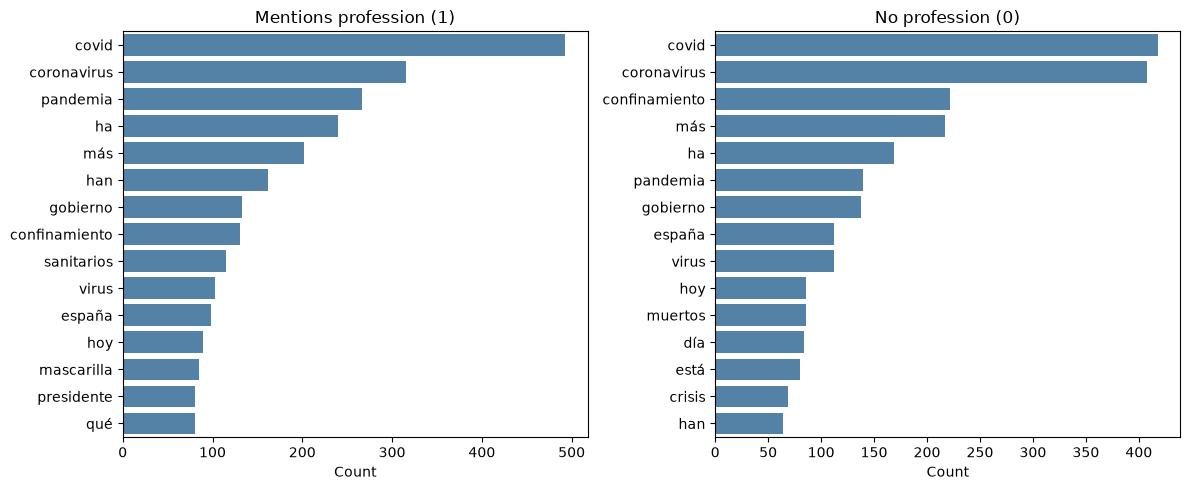

In [5]:
from collections import Counter

from sklearn.feature_extraction.text import CountVectorizer

# sklearn only ships English stopwords -- a short Spanish function-word list
# keeps the frequency counts from being dominated by "de", "que", "el", etc.
SPANISH_STOPWORDS = [
    "de", "la", "que", "el", "en", "y", "a", "los", "del", "se", "las",
    "por", "un", "para", "con", "no", "una", "su", "al", "lo", "como",
    "mas", "pero", "sus", "le", "ya", "o", "este", "si", "porque", "esta",
    "entre", "cuando", "muy", "sin", "sobre", "tambien", "me", "hasta",
    "hay", "donde", "quien", "desde", "todo", "nos", "durante", "todos",
    "uno", "les", "ni", "contra", "otros", "ese", "eso", "ante", "ellos",
    "e", "esto", "mi", "antes", "algunos", "que", "unos", "yo", "otro",
    "otras", "otra", "el", "tanto", "esa", "estos", "mucho", "quienes",
    "nada", "muchos", "cual", "poco", "ella", "estar", "estas", "algunas",
    "algo", "nosotros", "es", "son", "fue", "ser", "esta",
]


def top_words(texts, n=15):
    vec = CountVectorizer(stop_words=SPANISH_STOPWORDS, min_df=2)
    X = vec.fit_transform(texts)
    counts = X.sum(axis=0).A1
    freq = dict(zip(vec.get_feature_names_out(), counts))
    return Counter(freq).most_common(n)


pos_words = top_words(train_df.loc[train_df["label"] == 1, "text"])
neg_words = top_words(train_df.loc[train_df["label"] == 0, "text"])

print("Top words -- mentions profession (1):", pos_words)
print("Top words -- no profession (0):", neg_words)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, words, title in zip(
    axes, [pos_words, neg_words],
    ["Mentions profession (1)", "No profession (0)"],
):
    labels, values = zip(*words)
    sns.barplot(x=list(values), y=list(labels), ax=ax, color="steelblue")
    ax.set_title(title)
    ax.set_xlabel("Count")
plt.tight_layout()
plt.show()

The 15 most frequent words are nearly identical between classes -- `covid`, `coronavirus`, `pandemia`, `gobierno`, `virus`, `españa` top both lists, in a similar order. That's expected: every tweet in this dataset is about COVID-19, so raw word frequency mostly captures the shared topic, not the label. `sanitarios` (rank 9) is the only profession-related word to break into either top-15, and it's on the positive side. This is a useful negative result: it means TF-IDF's raw term weights alone won't separate the classes well -- the signal has to come from lower-frequency, more specific words instead (see below).

## Sample tweets by class

In [6]:
pd.set_option("display.max_colwidth", 150)

print("=== Mentions profession (1) ===")
for t in train_df.loc[train_df["label"] == 1, "text"].sample(5, random_state=42):
    print("-", t)

print("\n=== No profession (0) ===")
for t in train_df.loc[train_df["label"] == 0, "text"].sample(5, random_state=42):
    print("-", t)

=== Mentions profession (1) ===
- por si había alguna duda sí lo que buscaba la comunidad de madrid a través de la universidad complutense eran rastreadores que le saliesen gratis en mitad de la peor pandemia en un siglo han ofrecido puestos de rastreadores sin contrato dan ganas de llorar
- me cansé hilo con los vídeos que la en y su corresponsal en beijing no quisieron mostrarnos la realidad dl totalitarismo del pcc durante la crisis del virus y cómo sometieron a los disidentes los extorsionaron confinaron y maltrataron a sus mayores
- solo sé la prueba esté a la vista que ni el golpista de papel felipegonzález ni el invasor del irak aznar tuvieron jamás que luchar contra una pandemia tan terrible como ésta que padecemos sánchez sí solo por eso merece respeto los celos son malos consejeros siempre
- el verano llegó se termina la pandemia cuatro investigadores del csic responden a las preguntas sobre la situación del coronavirus de covid miércoles a las síguelo aquí envía tus pregunta

## Most frequent bigrams by class

Top bigrams -- mentions profession (1): [('guardia civil', np.int64(39)), ('estado alarma', np.int64(27)), ('ha sido', np.int64(24)), ('crisis covid', np.int64(23)), ('plena pandemia', np.int64(20)), ('crisis coronavirus', np.int64(19)), ('personal sanitario', np.int64(19)), ('pandemia covid', np.int64(16)), ('positivo coronavirus', np.int64(13)), ('comunidad madrid', np.int64(12)), ('coronavirus covid', np.int64(12)), ('lucha covid', np.int64(12)), ('pedro sánchez', np.int64(12)), ('profesionales sanitarios', np.int64(12)), ('frente covid', np.int64(11))]
Top bigrams -- no profession (0): [('crisis coronavirus', np.int64(21)), ('crisis covid', np.int64(18)), ('muertos coronavirus', np.int64(16)), ('pedro sánchez', np.int64(16)), ('día confinamiento', np.int64(14)), ('ha sido', np.int64(12)), ('estado alarma', np.int64(11)), ('buenos días', np.int64(10)), ('casos coronavirus', np.int64(10)), ('coronavirus españa', np.int64(10)), ('fernando simón', np.int64(10)), ('última hora', np.int6

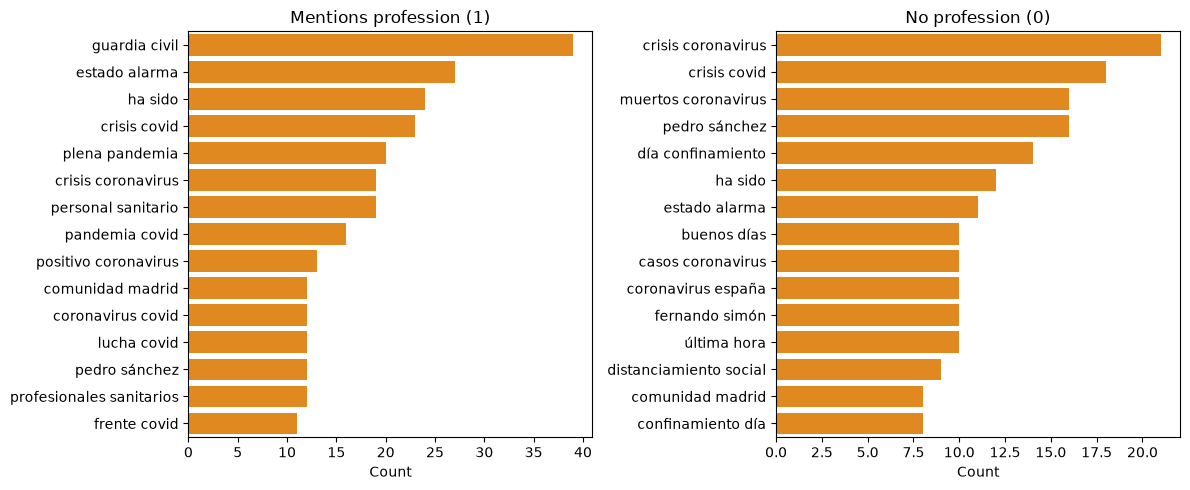

In [7]:
def top_ngrams(texts, ngram_range=(2, 2), n=15):
    vec = CountVectorizer(stop_words=SPANISH_STOPWORDS, ngram_range=ngram_range, min_df=2)
    X = vec.fit_transform(texts)
    counts = X.sum(axis=0).A1
    freq = dict(zip(vec.get_feature_names_out(), counts))
    return Counter(freq).most_common(n)


pos_bigrams = top_ngrams(train_df.loc[train_df["label"] == 1, "text"])
neg_bigrams = top_ngrams(train_df.loc[train_df["label"] == 0, "text"])

print("Top bigrams -- mentions profession (1):", pos_bigrams)
print("Top bigrams -- no profession (0):", neg_bigrams)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, bigrams, title in zip(
    axes, [pos_bigrams, neg_bigrams],
    ["Mentions profession (1)", "No profession (0)"],
):
    labels, values = zip(*bigrams)
    sns.barplot(x=list(values), y=list(labels), ax=ax, color="darkorange")
    ax.set_title(title)
    ax.set_xlabel("Count")
plt.tight_layout()
plt.show()

Bigrams show the same overlap for generic COVID phrases (`crisis coronavirus`, `crisis covid`, `estado alarma`, `comunidad madrid` appear in both top-15s). But two profession-specific bigrams surface only on the positive side: `personal sanitario` (19) and `profesionales sanitarios` (12) -- exactly the kind of multi-word expression a unigram count would miss. This is a concrete argument for `ngram_range=(1, 2)` in the baseline's `TfidfVectorizer` (`src/baseline.py`): dropping bigrams would throw away one of the few genuinely discriminative signals found in this EDA.

## Class-distinctive words

In [8]:
import numpy as np

vec = CountVectorizer(stop_words=SPANISH_STOPWORDS, min_df=5)
X = vec.fit_transform(train_df["text"])
vocab = vec.get_feature_names_out()

pos_mask = (train_df["label"] == 1).values
neg_mask = ~pos_mask

pos_counts = np.asarray(X[pos_mask].sum(axis=0)).ravel()
neg_counts = np.asarray(X[neg_mask].sum(axis=0)).ravel()

# Laplace smoothing so a word that is absent from one class doesn't divide by zero
pos_freq = (pos_counts + 1) / (pos_counts.sum() + len(vocab))
neg_freq = (neg_counts + 1) / (neg_counts.sum() + len(vocab))

log_ratio = pd.Series(np.log(pos_freq / neg_freq), index=vocab)

print("Top words skewed toward 'mentions profession' (1):")
print(log_ratio.sort_values(ascending=False).head(15))

print("\nTop words skewed toward 'no profession' (0):")
print(log_ratio.sort_values().head(15))

Top words skewed toward 'mentions profession' (1):
presidente      4.205203
sanitarios      3.858927
ministro        3.669685
médico          3.627125
policía         3.627125
erte            3.130688
políticos       3.056580
ministra        3.017360
director        2.889526
rastreadores    2.889526
policías        2.843006
alcalde         2.843006
ertes           2.794216
presidenta      2.794216
trabajadores    2.760314
dtype: float64

Top words skewed toward 'no profession' (0):
eleva            -2.504101
productos        -2.398741
tanta            -2.398741
evolución        -2.280958
señala           -2.280958
video            -2.073318
diarios          -1.993276
domiciliario     -1.993276
decisión         -1.993276
fallecimientos   -1.993276
fácil            -1.993276
crear            -1.993276
apuesta          -1.993276
registra         -1.993276
llegado          -1.993276
dtype: float64


This is the analysis that actually answers the question the raw frequency counts couldn't: once frequency is normalized per class, clear signal appears. Words skewed toward "mentions profession" are overwhelmingly job titles and roles -- `presidente`, `sanitarios`, `ministro`, `médico`, `policía`, `director`, `trabajadores` -- exactly what the task definition would predict, and with large log-ratios (up to 4.2).

The words skewed toward "no profession" are a different story: generic verbs and nouns (`eleva`, `señala`, `crear`, `registra`, `decisión`) with much weaker log-ratios (max ~2.5 in magnitude, vs. 4.2 on the positive side). That asymmetry says the negative class isn't a coherent topic with its own vocabulary -- it's everything else about COVID that doesn't happen to name a profession. A class with no strong lexical identity of its own is harder for a linear bag-of-words model to pin down, and it lines up with the baseline's confusion matrix (`[[521, 240], [58, 180]]`): 240 false positives vs. 58 false negatives -- the model over-predicts "mentions profession" because it's easier to detect a profession word than to confirm their absence.

**Takeaway for the modeling decision:** the classes are separable (profession words carry real, sizeable signal), so the task is learnable -- confirming the baseline's F1 of 0.55 isn't a data problem, it's a *linear-model* problem. TF-IDF only sees these specific words when they appear verbatim; it can't generalize to unseen role names, synonyms, or the many indirect ways a profession gets mentioned. That's the concrete, data-grounded case for trying BERTIN next, rather than just an assumption that "transformers are better."

## Baseline: TF-IDF + Logistic Regression

In [9]:
from src.baseline import main as run_baseline

baseline_report = run_baseline()

TF-IDF + Logistic Regression  (threshold=0.51)
  F1:       0.5471
  Accuracy: 0.7017
  Confusion matrix: [[521, 240], [58, 180]]


## BERTIN: fine-tuned transformer

BERTIN RoBERTa (`bertin-project/bertin-roberta-base-spanish`) was fine-tuned for 4
epochs via `src/train.py`. That needs a GPU (roughly 15 minutes on a free Colab
T4) and isn't re-run inside this notebook. Its validation results, from the
training run this repo is based on:

| Metric | Value |
|---|---|
| F1 (threshold 0.42, tuned on validation) | 0.878 |
| Accuracy | 0.942 |

See the README for the full comparison against the baseline above, and for the
decision-threshold bug this repo fixes (the original notebook tuned a threshold
and then never applied it to the final predictions).

## Conclusion

The TF-IDF baseline lands at F1 ~ 0.55, well below BERTIN's F1 ~ 0.88 -- a 33-point
gap. For this task, the transformer's training cost is justified: language
pretrained specifically on Spanish appears to capture how profession mentions are
phrased in ways a bag-of-words model can't.

See `src/predict.py` for generating final test predictions with the (bug-fixed)
tuned threshold, and `app.py` for a live demo.